# Granularity Experiment

Notebook flow:
1. Oversampling comparison (binary) — pick best sampler
2. TF-IDF cosine similarity intra-game — identify natural class merge candidates
3. Generate src/label_schemes.py from empirical findings
4. Incremental granularity experiment — all n_classes, all models, full metrics
5. Sweet spot plots

## 0. Imports & CONFIG

In [30]:
# libraries 
import warnings, textwrap
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
# logistic regression library here 
from sklearn.linear_model import LogisticRegression

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.tokenizer import tokenize
from src.loaders import load_wot, load_dota
from src.pipelines import build_pipe, default_classifiers
from src.scoring import cv_score

# config 
CONFIG = {
    'seed': 7524,
    'cv_folds': 5,
    'text_col': 'message',
    'label_col': 'label',
    'label_schemes_path': Path('../../src/label_schemes.py'),
}

# seed
seed = CONFIG['seed']
# stratified k-fold cross-validation
cv   = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=seed)
np.random.seed(seed)

# classes
WOT_CLASSES  = {0:'Non-Toxic', 1:'Insults', 2:'Other Offensive Texts',
                3:'Hate and Harassment', 4:'Threats', 5:'Extremism'}
DOTA_CLASSES = {0:'Non-Toxic', 1:'Ego', 2:'Aggression', 3:'Impolite'}
print('CONFIG loaded.')


CONFIG loaded.


**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

## 1. Oversampling Comparison (Binary)

In [31]:
# Compare all 4 oversamplers at multiclass experiment. 
wot_train_raw  = load_wot('train')
wot_val_raw    = load_wot('val')
dota_train_raw = load_dota('train')
dota_val_raw   = load_dota('val')

# list of oversamplers 
OVERSAMPLERS = {
    'RandomOverSampler': RandomOverSampler(random_state=seed),
    'SMOTE':             SMOTE(random_state=seed),
    'ADASYN':            ADASYN(random_state=seed),
}

# initiate logistic regression
ref_clf = LogisticRegression(C=1.0, max_iter=2000, random_state=seed, n_jobs=1)

# datasets 
DATASETS = {
    'WoT':  (wot_train_raw[CONFIG['text_col']], wot_train_raw[CONFIG['label_col']]),
    'Dota': (dota_train_raw[CONFIG['text_col']], dota_train_raw[CONFIG['label_col']]),
}
# list for results 
os_results = []

# iterate over datasets and oversamplers, evaluate with cv and store results
for game, (X_tr, y_tr) in DATASETS.items():
    print(f'=== {game} ===')
    # iterate oversamplers
    for os_name, sampler in OVERSAMPLERS.items():
        # build pipeline with cloned classifier and current oversampler, evaluate with cv and store results
        pipe = build_pipe(ref_clf, oversampler=sampler)
        # cv_score returns dict with cv_f1, cv_recall, cv_precision
        scores = cv_score(pipe, X_tr, y_tr, cv=cv)
        # print results and store in list
        print(f' {os_name:<20} cv_f1={scores["cv_f1"]:.4f} '
              f'recall={scores["cv_recall"]:.4f} '
              f'precision={scores["cv_precision"]:.4f}')
        os_results.append({'game': game, 'oversampler': os_name, **scores})

# as DataFrame for easier analysis
os_df = pd.DataFrame(os_results)

print('\n--- Best per game ---')
# for each game, find the oversampler with best cv_f1 and print it
for game in DATASETS:
    # filter os_df for current game, sort by cv_f1 descending and take the first row (best)
    best = os_df[os_df['game'] == game].sort_values('cv_f1', ascending=False).iloc[0]
    # print the best oversampler and its cv_f1 score
    print(f'{game}: {best["oversampler"]} (cv_f1={best["cv_f1"]:.4f})')


=== WoT ===
 RandomOverSampler    cv_f1=0.6062 recall=0.6759 precision=0.5987
 SMOTE                cv_f1=0.6043 recall=0.6788 precision=0.5978
 ADASYN               cv_f1=0.6021 recall=0.6756 precision=0.5924
=== Dota ===
 RandomOverSampler    cv_f1=0.8545 recall=0.8731 precision=0.8405
 SMOTE                cv_f1=0.8533 recall=0.8726 precision=0.8385
 ADASYN               cv_f1=0.8335 recall=0.8720 precision=0.8061

--- Best per game ---
WoT: RandomOverSampler (cv_f1=0.6062)
Dota: RandomOverSampler (cv_f1=0.8545)


The gains are very marginal. So instead of using artifical oversamplers, it is safer to use `RandomOversampler`. 

## 2. Define Potential Label Schemes

In [32]:
# Incremental severity-based splits — each step separates the next hardest class.
# Build from binary upward: merge similar first, split severe last.
# Labels must be 0-indexed and contiguous.

# n=2: binary
WOT_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}

# n=3: Non-Toxic / Insults+OtherOffensive (Mild toxicity) / Hate+Threats+Extremism (Severe toxicity)
WOT_SCHEME_3 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}

# n=4: Non-Toxic / Insults+OtherOffensive / Hate / Threats+Extremism
WOT_SCHEME_4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3}

# n=5: Non-Toxic / Insults+OtherOffensive / Hate / Threats / Extremism
WOT_SCHEME_5 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 4}

# n=6: identity
WOT_SCHEME_6 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

# Dota: no merge candidates found, but we can iterate just to experiment
# binary
DOTA_SCHEME_2 = {0: 0, 1: 1, 2: 1, 3: 1}

# n=3: Non-Toxic / Ego + Impolite (Mild toxicity) / Agression (Severe toxicity)
DOTA_SCHEME_3 = {0: 0, 1: 1, 2: 2, 3: 1}

# n=4: Non-Toxic / Ego / Agression / Impolite
DOTA_SCHEME_4 = {0: 0, 1: 1, 2: 2, 3: 3}

WOT_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
    4: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats+Extremism'],
    5: ['Non-Toxic', 'Insults/Other Offensive', 'Hate', 'Threats', 'Extremism'],
    6: list(WOT_CLASSES.values()),
}

DOTA_CLASS_NAMES = {
    2: ['Non-Toxic', 'Toxic'],
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
    4: ['Non-Toxic', 'Ego', 'Aggression', 'Impolite'],
}

WOT_SCHEMES  = {2: WOT_SCHEME_2, 3: WOT_SCHEME_3, 4: WOT_SCHEME_4,
                5: WOT_SCHEME_5, 6: WOT_SCHEME_6}
DOTA_SCHEMES = {2: DOTA_SCHEME_2, 3: DOTA_SCHEME_3, 4: DOTA_SCHEME_4}

print('Schemes defined.')
print('WoT schemes:', list(WOT_SCHEMES.keys()))
print('Dota schemes:', list(DOTA_SCHEMES.keys()))

Schemes defined.
WoT schemes: [2, 3, 4, 5, 6]
Dota schemes: [2, 3, 4]


## 3. Write src/label_schemes.py

In [33]:
# Generate src/label_schemes.py as a product of this notebook's analysis.
# This file is the empirical output
label_schemes_content = textwrap.dedent(f"""\
    # Auto-generated by notebooks/01_granularity_experiment.ipynb
    # Based on TF-IDF cosine similarity analysis - edit Section 3 of that notebook to update.

    WOT_SCHEMES = {WOT_SCHEMES!r}

    DOTA_SCHEMES = {DOTA_SCHEMES!r}

    WOT_CLASS_NAMES = {WOT_CLASS_NAMES!r}

    DOTA_CLASS_NAMES = {DOTA_CLASS_NAMES!r}
    """)

CONFIG['label_schemes_path'].write_text(label_schemes_content, encoding='utf-8')
print(f'Written: {CONFIG["label_schemes_path"]}')
print('Contents preview:')
print(label_schemes_content[:400])

Written: ..\..\src\label_schemes.py
Contents preview:
# Auto-generated by notebooks/01_granularity_experiment.ipynb
# Based on TF-IDF cosine similarity analysis - edit Section 3 of that notebook to update.

WOT_SCHEMES = {2: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}, 3: {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}, 4: {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3}, 5: {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 4}, 6: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}}

DOTA_SCHEMES = {2: {0: 0, 


## 5. Incremental Granularity Experiment

In [34]:
# function for granularity track 
def run_granularity_track(game, raw_train, schemes):
    # list or results 
    results = []
    # iterate over schemes (n_classes and mapping)
    for n_classes, scheme in schemes.items():
        # copy train data 
        train = raw_train.copy()
        # map label to the scheme
        train[CONFIG['label_col']] = train[CONFIG['label_col']].astype(int).map(scheme)

        # apply the scheme 
        X_train = train[CONFIG['text_col']]
        y_train = train[CONFIG['label_col']]
        
        # assign variables for best model tracking
        best_f1, best_name, best_rec, best_prec = -1, None, 0, 0

        # iterate classifiers
        for clf_name, clf in default_classifiers(seed).items():
            # build pipeline with classifier and current oversampler, evaluate with cv and store results
            pipe = build_pipe(clf, oversampler=RandomOverSampler(random_state=seed))
            # cross-validation scores
            scores = cv_score(pipe, X_train, y_train, cv=cv)
            
            # print macro-averaged cv scores and store in registry
            print(f'{game} n={n_classes} {clf_name:<22} '
                  f'f1={scores["cv_f1"]:.4f} '
                  f'rec={scores["cv_recall"]:.4f} '
                  f'prec={scores["cv_precision"]:.4f}')

            # if the latest model has best cv_f1 so far, update best_f1 and best_name
            if scores['cv_f1'] > best_f1:
                best_f1, best_name = scores['cv_f1'], clf_name
                best_rec, best_prec = scores['cv_recall'], scores['cv_precision']  # track together

        # append best model for current scheme to results list and print summary
        results.append({'game': game, 'n_classes': n_classes,
                        'best_model': best_name, 'best_cv_f1': round(best_f1, 4), 
                        'best_cv_recall': round(best_rec, 4),
                        'best_cv_precision': round(best_prec, 4)})
        print(f' -> best: {best_name} ({best_f1:.4f})\n')

    # return full dataframe
    return pd.DataFrame(results)

# Run the granularity track for both games and print results
print('=== WoT incremental ===')
wot_results = run_granularity_track('WoT',  wot_train_raw,  WOT_SCHEMES)

print('\n=== Dota incremental ===')
dota_results = run_granularity_track('Dota', dota_train_raw, DOTA_SCHEMES)

# Print summary tables for both games
print('\nWoT:');  print(wot_results.to_string(index=False))
print('\nDota:'); print(dota_results.to_string(index=False))


=== WoT incremental ===
WoT n=2 Logistic Regression    f1=0.8711 rec=0.8512 prec=0.8919
WoT n=2 Naive Bayes            f1=0.8356 rec=0.8875 prec=0.7895
WoT n=2 LinearSVC              f1=0.8736 rec=0.8668 prec=0.8805
 -> best: LinearSVC (0.8736)

WoT n=3 Logistic Regression    f1=0.7779 rec=0.8171 prec=0.7548
WoT n=3 Naive Bayes            f1=0.6888 rec=0.8171 prec=0.6505
WoT n=3 LinearSVC              f1=0.7772 rec=0.8095 prec=0.7561
 -> best: Logistic Regression (0.7779)

WoT n=4 Logistic Regression    f1=0.6595 rec=0.7202 prec=0.6362
WoT n=4 Naive Bayes            f1=0.5493 rec=0.7510 prec=0.5102
WoT n=4 LinearSVC              f1=0.6547 rec=0.7003 prec=0.6369
 -> best: Logistic Regression (0.6595)

WoT n=5 Logistic Regression    f1=0.6058 rec=0.6616 prec=0.6306
WoT n=5 Naive Bayes            f1=0.4473 rec=0.6840 prec=0.4128
WoT n=5 LinearSVC              f1=0.5880 rec=0.6303 prec=0.6360
 -> best: Logistic Regression (0.6058)

WoT n=6 Logistic Regression    f1=0.6062 rec=0.6759 prec=0

## 6. Sweet Spot Plots

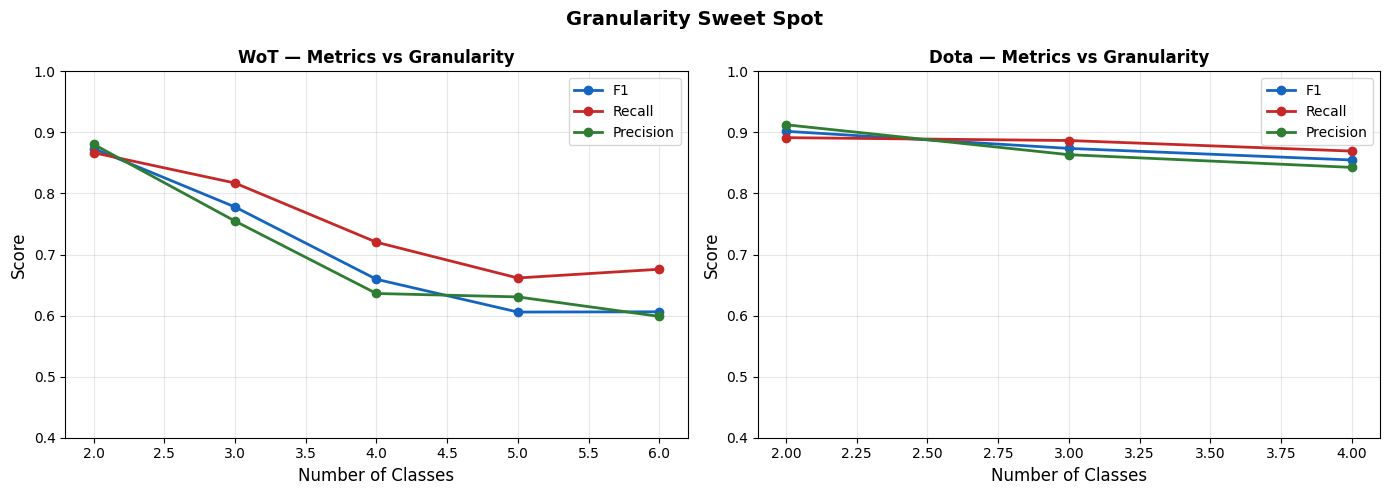

In [35]:
# combine both games into one frame for unified plotting
all_results = pd.concat([wot_results, dota_results], ignore_index=True)

# metrics that we want to plot
metrics = [
    ('best_cv_f1',        'F1',        '#1565C0'),
    ('best_cv_recall',    'Recall',    '#C62828'),
    ('best_cv_precision', 'Precision', '#2E7D32'),
]

# unique games 
games = all_results['game'].unique()

# plotting
fig, axes = plt.subplots(1, len(games), figsize=(7 * len(games), 5))
if len(games) == 1:
    axes = [axes]

# plot each metric for each game
for ax, game in zip(axes, games):
    gdf = all_results[all_results['game'] == game]
    for col, label, color in metrics:
        ax.plot(gdf['n_classes'], gdf[col],
                marker='o', linewidth=2, color=color, label=label)
    # labels, title, legend, grid
    # xlabel
    ax.set_xlabel('Number of Classes', fontsize=12)
    # ylabel
    ax.set_ylabel('Score', fontsize=12)
    # title with game name
    ax.set_title(f'{game} — Metrics vs Granularity', fontweight='bold')
    # legend 
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

# suptitle
plt.suptitle('Granularity Sweet Spot', fontweight='bold', fontsize=14)
plt.tight_layout()

# save figure
plt.savefig('../../data/results/granularity_sweet_spot.png', dpi=150, bbox_inches='tight')
plt.show()